# HackerRank Data Scientist Hiring Test: Predict Life Expectancy

Governments, research institutes, and organizations like the United Nations and the World Bank try to understand the relationship between the life expectancy of a country or a geographical area and socioeconomic factors. Such analysis is valuable in deciding economic and social policies. Can you construct a reliable model that predicts the life expectancy of an area (country, region, group of countries) using socioeconomic variables and identify how different features influence that?

Every row of the train_data or the test_data represents socioeconomic variables of a geographical area. That area could be a country, a group of countries, a region or a big country’s provision.

**Goal:**

For every row in the test data, you must predict the value of the life expectancy. The predictions must be saved in a .csv file with the name ‘submission.csv’.

The CSV file must have two columns.
* The first column must be the index of the test set
* The second column must have the predicted value of every corresponding index value.

**Evaluation Metric:**

The metric used for evaluating the performance of the predictive model will be the **mean absolute error** of the predictions from the ground truth (the real values of the life expectancy for every row in the test set).

In [1]:
#Libraries
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 101)

#Visualization libraries and settings
import seaborn as sns
import matplotlib.pyplot as plt

#Imputation libraries
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

#Preprocessing libraries
import re

1. Data Wrangling & Visualization

In [2]:
#Load data
data = pd.read_csv('train.csv', index_col=0)

In [3]:
data.head()

,surface_area,agricultural_land,forest_area,armed_forces_total,urban_pop_major_cities,urban_pop_minor_cities,national_income,inflation_annual,inflation_monthly,inflation_weekly,mobile_subscriptions,internet_users,secure_internet_servers_total,improved_sanitation,women_parliament_seats_rate,life_expectancy
0,120540.0,2.632839e+06,5.417843e+06,1379000.0,55.747169,4.688831,unknown,NaN,NaN,NaN,less than 1 per person,0 per 1000 people,NaN,high access,[0%-25%),69.494195
1,752610.0,2.403039e+07,4.957554e+07,16500.0,16.890687,23.136313,very low,NaN,0.581473,NaN,less than 1 per person,154 per 1000 people,2.623624e+06,low access,[0%-25%),59.237366
2,1396.0,3.000000e+03,8.000000e+01,NaN,18.390090,23.139910,unknown,NaN,NaN,NaN,more than 1 per person,90 per 100 people,1.656589e+09,no info,unknown,81.300000
3,2758812.0,1.228845e+08,1.050943e+08,1518650.0,50.966885,24.522427,high,1.374906,NaN,NaN,more than 1 per person,76 per 100 people,6.625072e+08,very high access,[25%-50%),81.373197
4,340.0,1.100000e+04,1.699000e+04,NaN,5.311885,30.271115,unknown,-0.044229,NaN,NaN,more than 1 per person,350 per 1000 people,2.832808e+07,very high access,[25%-50%),73.193561


In [4]:
#explore columns
data.columns

Index(['surface_area', 'agricultural_land', 'forest_area',
       'armed_forces_total', 'urban_pop_major_cities',
       'urban_pop_minor_cities', 'national_income', 'inflation_annual',
       'inflation_monthly', 'inflation_weekly', 'mobile_subscriptions',
       'internet_users', 'secure_internet_servers_total',
       'improved_sanitation', 'women_parliament_seats_rate',
       'life_expectancy'],
      dtype='object')

In [5]:
#Description
data.describe()

,surface_area,agricultural_land,forest_area,armed_forces_total,urban_pop_major_cities,urban_pop_minor_cities,inflation_annual,inflation_monthly,inflation_weekly,secure_internet_servers_total,life_expectancy
count,3.620000e+02,3.580000e+02,3.570000e+02,3.180000e+02,360.000000,360.000000,146.000000,156.000000,20.000000,3.520000e+02,362.000000
mean,4.021884e+06,1.594881e+08,1.204151e+08,9.849864e+05,27.659456,29.175242,1.681539,0.475969,0.396478,2.949654e+08,71.059691
std,1.234491e+07,4.964143e+08,3.796623e+08,2.994686e+06,20.512885,21.206494,0.980308,0.153430,0.203583,7.234006e+08,8.332818
min,3.030000e+01,3.000000e+02,0.000000e+00,5.000000e+01,0.091444,0.074575,-2.372263,0.250543,0.209993,4.002500e+04,48.850634
25%,2.783000e+04,1.054198e+06,4.951445e+05,1.218000e+04,10.624625,11.013743,1.202953,0.347799,0.232118,3.468446e+06,65.469854
50%,2.037745e+05,5.360256e+06,3.928535e+06,5.352500e+04,24.459439,26.735127,1.762683,0.459790,0.297938,2.671228e+07,73.238024
75%,1.081610e+06,4.221935e+07,2.241297e+07,2.598000e+05,38.587177,43.499418,2.485675,0.577340,0.537541,2.173937e+08,77.125610
max,1.343253e+08,5.067600e+09,4.132117e+09,2.720662e+07,92.409069,89.142904,2.997694,0.810152,0.781527,8.207343e+09,83.480488


In [6]:
#Shape of data
data.shape

(362, 16)

                   surface_area  agricultural_land  forest_area
surface_area           1.000000           0.987256     0.983576
agricultural_land      0.987256           1.000000     0.956057
forest_area            0.983576           0.956057     1.000000


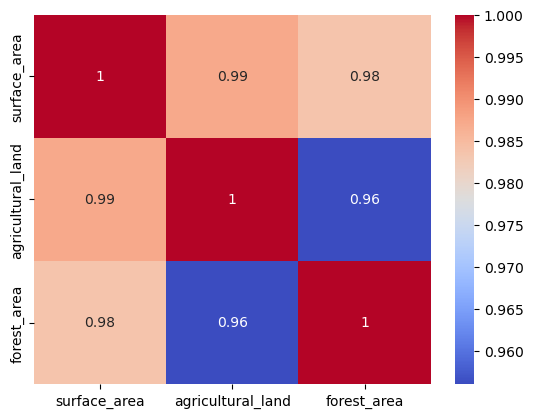

In [7]:
#The surface area is smaller than the agricultural_land and the forest area, which is not possible. 

# Check if these features are redundant
cols = ['surface_area', 'agricultural_land', 'forest_area']
print(data[cols].corr())

# Visual check
sns.heatmap(data[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
#Check for missing values
data.isnull().sum()

surface_area                       0
agricultural_land                  4
forest_area                        5
armed_forces_total                44
urban_pop_major_cities             2
urban_pop_minor_cities             2
national_income                    0
inflation_annual                 216
inflation_monthly                206
inflation_weekly                 342
mobile_subscriptions               0
internet_users                     0
secure_internet_servers_total     10
improved_sanitation                0
women_parliament_seats_rate        0
life_expectancy                    0
dtype: int64

In [9]:
# 1. Feature Engineering: Create Ratios
# Multiply by 100 the surface area in test and train df
train_df = data.copy()
train_df['surface_area'] = train_df['surface_area'] * 100
test = pd.read_csv('test.csv', index_col=0)
test_df = test.copy()
test_df['surface_area'] = test_df['surface_area'] * 100

# 2. Create the Ratios
for df in [train_df, test_df]:
    df['agri_pct'] = df['agricultural_land'] / (df['surface_area'])
    df['forest_pct'] = df['forest_area'] / (df['surface_area'])
    
# 3. Drop redundant features to solve the 0.98 correlation issue
# We drop the absolute km2/hectare values and only keep the Ratios + original surface_area
cols_to_drop = ['agricultural_land', 'forest_area']
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

In [10]:
#It doesn't make sense to have inflation_annual, inflation_monthly and inflation_weekly.
# They have many missing values and they are highly correlated. We will keep only the annual one, which has the least missing values.
# We will use the monthly and weekly inflation data to impute the missing values in the annual inflation feature.
# Function to consolidate inflation data
def consolidate_inflation(df):
    # 1. Fill missing annual using monthly (Annual = Monthly * 12)
    df['inflation_annual'] = df['inflation_annual'].fillna(df['inflation_monthly'] * 12)
    
    # 2. Fill remaining missing annual using weekly (Annual = Weekly * 52)
    df['inflation_annual'] = df['inflation_annual'].fillna(df['inflation_weekly'] * 52)
    
    # 3. Drop the redundant features to solve multicollinearity
    df.drop(['inflation_monthly', 'inflation_weekly'], axis=1, inplace=True)
    
    return df

# Apply to both datasets
train_df = consolidate_inflation(train_df)
test_df = consolidate_inflation(test_df)

In [11]:
# 1. Identify the target column
target = 'life_expectancy'

# 2. Get numeric columns but REMOVE the target from the list
# .drop(target) ensures we only look at features present in both datasets
numeric_features = train_df.select_dtypes(include=[np.number]).columns.drop(target)

# 3. Fit and transform the training features
train_df[numeric_features] = imputer.fit_transform(train_df[numeric_features])

# 4. Transform the test features (now it works because 'life_expectancy' is not in the list)
test_df[numeric_features] = imputer.transform(test_df[numeric_features])

NameError: name 'imputer' is not defined

In [12]:
#Types of data
data.dtypes

surface_area                     float64
agricultural_land                float64
forest_area                      float64
armed_forces_total               float64
urban_pop_major_cities           float64
urban_pop_minor_cities           float64
national_income                   object
inflation_annual                 float64
inflation_monthly                float64
inflation_weekly                 float64
mobile_subscriptions              object
internet_users                    object
secure_internet_servers_total    float64
improved_sanitation               object
women_parliament_seats_rate       object
life_expectancy                  float64
dtype: object

In [13]:
#Check the value counts of the variables
train_df['national_income'].value_counts()

# 1. Define the ordinal mapping
income_mapping = {
    'very low': 1,
    'low': 2,
    'medium low': 3,
    'medium high': 4,
    'high': 5,
    'very high': 6,
    'unknown': np.nan  # Set to NaN so we can impute it accurately later
}

# 2. Apply the mapping to both DataFrames
train_df['national_income'] = train_df['national_income'].map(income_mapping)
test_df['national_income'] = test_df['national_income'].map(income_mapping)

In [14]:
#Check the value counts of the variables
train_df['mobile_subscriptions'].value_counts()

# Define the binary mapping
mobile_mapping = {
    'less than 1 per person': 0,
    'more than 1 per person': 1,
    'more than 2 per person': 1, # Merged into 'More than 1'
    'more than 3 per person': 1, # Merged into 'More than 1'
    'unknown': np.nan            # Let the imputer handle this
}

# Apply to both
train_df['mobile_subscriptions'] = train_df['mobile_subscriptions'].map(mobile_mapping)
test_df['mobile_subscriptions'] = test_df['mobile_subscriptions'].map(mobile_mapping)

In [15]:
train_df.head()

,surface_area,armed_forces_total,urban_pop_major_cities,urban_pop_minor_cities,national_income,inflation_annual,mobile_subscriptions,internet_users,secure_internet_servers_total,improved_sanitation,women_parliament_seats_rate,life_expectancy,agri_pct,forest_pct
0,12054000.0,1379000.0,55.747169,4.688831,NaN,NaN,0.0,0 per 1000 people,NaN,high access,[0%-25%),69.494195,0.218420,0.449464
1,75261000.0,16500.0,16.890687,23.136313,1.0,6.977676,0.0,154 per 1000 people,2.623624e+06,low access,[0%-25%),59.237366,0.319294,0.658715
2,139600.0,NaN,18.390090,23.139910,NaN,NaN,1.0,90 per 100 people,1.656589e+09,no info,unknown,81.300000,0.021490,0.000573
3,275881200.0,1518650.0,50.966885,24.522427,5.0,1.374906,1.0,76 per 100 people,6.625072e+08,very high access,[25%-50%),81.373197,0.445426,0.380940
4,34000.0,NaN,5.311885,30.271115,NaN,-0.044229,1.0,350 per 1000 people,2.832808e+07,very high access,[25%-50%),73.193561,0.323529,0.499706


In [16]:
#check the value counts of the variables
#train_df['internet_users'].value_counts()

def convert_internet_to_pct(val):
    if pd.isna(val) or str(val).lower() == 'unknown':
        return np.nan
    
    # Extract all numbers from the string
    numbers = re.findall(r"[-+]?\d*\.\d+|\d+", str(val))
    if not numbers:
        return np.nan
    
    val_num = float(numbers[0])
    
    # Logic for denominator
    if 'per 1000' in str(val):
        return val_num / 10  # Convert 154 per 1000 -> 15.4%
    elif 'per 100' in str(val):
        return val_num       # 41 per 100 -> 41%
    
    return val_num # Fallback

# Apply to both DataFrames
train_df['internet_users'] = train_df['internet_users'].apply(convert_internet_to_pct)
test_df['internet_users'] = test_df['internet_users'].apply(convert_internet_to_pct)

In [17]:
#check the value counts of the variables
train_df['improved_sanitation'].value_counts()

# 1. Define the ordinal mapping
mapping = {
    'very low access': 1,
    'low access': 2,
    'medium access': 3,
    'high access': 4,
    'very high access': 5,
    'no info': np.nan  # Set to NaN so we can impute it accurately later
}

# 2. Apply the mapping to both DataFrames
train_df['improved_sanitation'] = train_df['improved_sanitation'].map(mapping)
test_df['improved_sanitation'] = test_df['improved_sanitation'].map(mapping)

In [18]:
train_df.head()  

,surface_area,armed_forces_total,urban_pop_major_cities,urban_pop_minor_cities,national_income,inflation_annual,mobile_subscriptions,internet_users,secure_internet_servers_total,improved_sanitation,women_parliament_seats_rate,life_expectancy,agri_pct,forest_pct
0,12054000.0,1379000.0,55.747169,4.688831,NaN,NaN,0.0,0.0,NaN,4.0,[0%-25%),69.494195,0.218420,0.449464
1,75261000.0,16500.0,16.890687,23.136313,1.0,6.977676,0.0,15.4,2.623624e+06,2.0,[0%-25%),59.237366,0.319294,0.658715
2,139600.0,NaN,18.390090,23.139910,NaN,NaN,1.0,90.0,1.656589e+09,NaN,unknown,81.300000,0.021490,0.000573
3,275881200.0,1518650.0,50.966885,24.522427,5.0,1.374906,1.0,76.0,6.625072e+08,5.0,[25%-50%),81.373197,0.445426,0.380940
4,34000.0,NaN,5.311885,30.271115,NaN,-0.044229,1.0,35.0,2.832808e+07,5.0,[25%-50%),73.193561,0.323529,0.499706


In [19]:
#check the value counts of the variables
#train_df['women_parliament_seats_rate'].value_counts()

#Mapping intervals to their midpoints
mapping_parliament = {
    '[0%-25%)': 12.5,
    '[25%-50%)': 37.5,
    '[50%-75%)': 62.5,
    '[75%-100%]': 87.5,
    'unknown': np.nan  # Very important: set to NaN for imputation
}

# Apply to both datasets
train_df['women_parliament_seats_rate'] = train_df['women_parliament_seats_rate'].map(mapping_parliament)
test_df['women_parliament_seats_rate'] = test_df['women_parliament_seats_rate'].map(mapping_parliament)

In [20]:
train_df.head()

,surface_area,armed_forces_total,urban_pop_major_cities,urban_pop_minor_cities,national_income,inflation_annual,mobile_subscriptions,internet_users,secure_internet_servers_total,improved_sanitation,women_parliament_seats_rate,life_expectancy,agri_pct,forest_pct
0,12054000.0,1379000.0,55.747169,4.688831,NaN,NaN,0.0,0.0,NaN,4.0,12.5,69.494195,0.218420,0.449464
1,75261000.0,16500.0,16.890687,23.136313,1.0,6.977676,0.0,15.4,2.623624e+06,2.0,12.5,59.237366,0.319294,0.658715
2,139600.0,NaN,18.390090,23.139910,NaN,NaN,1.0,90.0,1.656589e+09,NaN,NaN,81.300000,0.021490,0.000573
3,275881200.0,1518650.0,50.966885,24.522427,5.0,1.374906,1.0,76.0,6.625072e+08,5.0,37.5,81.373197,0.445426,0.380940
4,34000.0,NaN,5.311885,30.271115,NaN,-0.044229,1.0,35.0,2.832808e+07,5.0,37.5,73.193561,0.323529,0.499706


In [21]:
# Define features (everything except the target)
target = 'life_expectancy'
features = train_df.columns.drop(target)

# Initialize and fit the imputer again, now that all features are numeric and properly encoded
imputer = IterativeImputer(random_state=42)
train_df[features] = imputer.fit_transform(train_df[features])
test_df[features] = imputer.transform(test_df[features])

2. Visualization, Modeling, Machine Learning

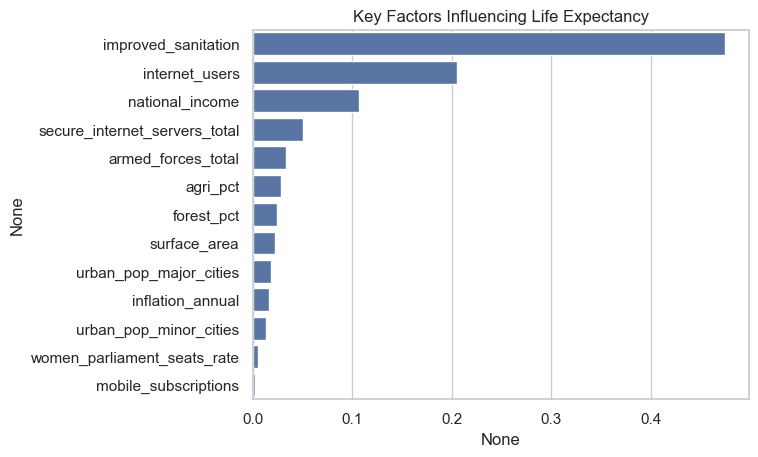

C:\Users\celso\AppData\Local\Temp\ipykernel_21552\1755151839.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df[target], label='Actual', shade=True)
C:\Users\celso\AppData\Local\Temp\ipykernel_21552\1755151839.py:39: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test_predictions, label='Predicted', shade=True)


<Axes: xlabel='life_expectancy', ylabel='Density'>

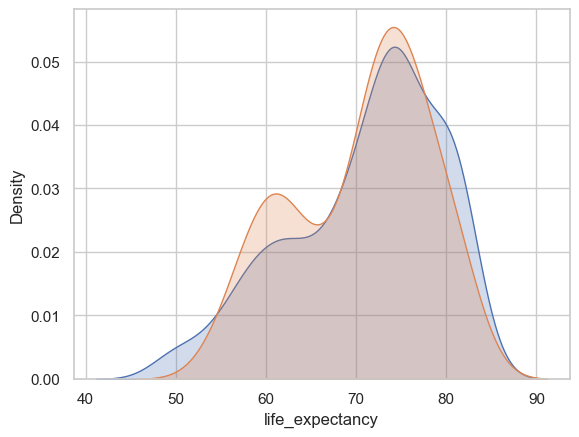

In [90]:
#Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare X and y
X = train_df[features]
y = train_df[target]

# 2. Initialize the model 
# n_estimators=100 is a safe default; random_state ensures your results are reproducible
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 3. Fit the model
model.fit(X, y)

# 4. Predict on the test set
test_predictions = model.predict(test_df[features])

# Create the submission dataframe
# Assuming your test_df still has the original index from the CSV
submission = pd.DataFrame({
    'index': test_df.index,
    'life_expectancy': test_predictions
})

# Save to CSV
# index=False because we already included 'index' as a column
submission.to_csv('submissionRF.csv', index=False)

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importances, y=importances.index)
plt.title("Key Factors Influencing Life Expectancy")
plt.show()


# Check to see if distribution of actual target values is close to the distribution of predicted target values
sns.kdeplot(train_df[target], label='Actual', shade=True)
sns.kdeplot(test_predictions, label='Predicted', shade=True)

# Trying XGBoost

Model Selection & Optimization Strategy:
To maximize predictive accuracy and ensure robust generalization, I implemented an XGBoost Regressor within a scikit-learn Pipeline.

Key features of this approach:

Data Leakage Protection: By nesting the StandardScaler within the cross-validation pipeline, I ensured that feature scaling parameters were computed only on training folds.

Spatial Validation (GroupKFold): I utilized GroupKFold to prevent the model from over-learning specific regional patterns, ensuring the validation scores reflect true performance on unseen geographical areas.

Hyperparameter Tuning: A 50-iteration RandomizedSearchCV was used to optimize the model's learning rate, depth, and regularization parameters, balancing bias and variance."

In [22]:
import sys
!{sys.executable} -m pip install xgboost

In [23]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score

# 1. Setup Data
target = 'life_expectancy'
features = train_df.columns.drop([target])

X = train_df[features]
y = train_df[target]

# IMPORTANT: Define your groups (e.g., 'surface_area' or 'national_income') 
# to ensure similar geographic areas stay together in the same fold.
# For this test, we can use 'national_income' or an ID if available.
groups = train_df['national_income'] 

# 2. Define the Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(objective='reg:squarederror', random_state=42))
])

# 3. Define Hyperparameter Search Space
param_distributions = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__max_depth': [3, 4, 6, 8],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 0.9],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9],
    'xgb__gamma': [0, 0.1, 0.2]
}

# 4. Randomized Search with GroupKFold
gkf = GroupKFold(n_splits=5)

search = RandomizedSearchCV(
    pipeline, 
    param_distributions=param_distributions, 
    n_iter=50, 
    cv=gkf, 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1, 
    random_state=42
)

# 5. Execute Search
# We pass 'groups' to the fit method so GroupKFold knows how to split
search.fit(X, y, groups=groups)

# 6. Results & Best Model
print(f"Best R2 Score from CV: {search.best_score_:.4f}")
print(f"Best Params: {search.best_params_}")

# Final model is already refitted on the whole dataset by RandomizedSearchCV
final_model = search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best R2 Score from CV: 0.2897
Best Params: {'xgb__subsample': 0.7, 'xgb__n_estimators': 100, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.9}


In [24]:
# Calculate Final RMSE for the best CV score
best_index = search.best_index_
cv_results = search.cv_results_
mean_test_score = cv_results['mean_test_score'][best_index]

# Predictions for submission
test_preds = final_model.predict(test_df[features])

submission = pd.DataFrame({
    'index': test_df.index,
    'life_expectancy': test_preds
})
submission.to_csv('submission_XG.csv', index=False)

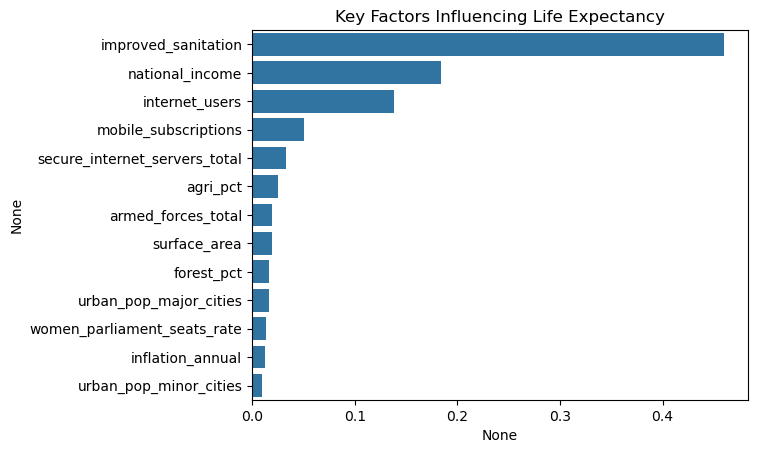

C:\Users\celso\AppData\Local\Temp\ipykernel_4620\307893119.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train_df[target], label='Actual', shade=True)
C:\Users\celso\AppData\Local\Temp\ipykernel_4620\307893119.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test_preds, label='Predicted', shade=True)


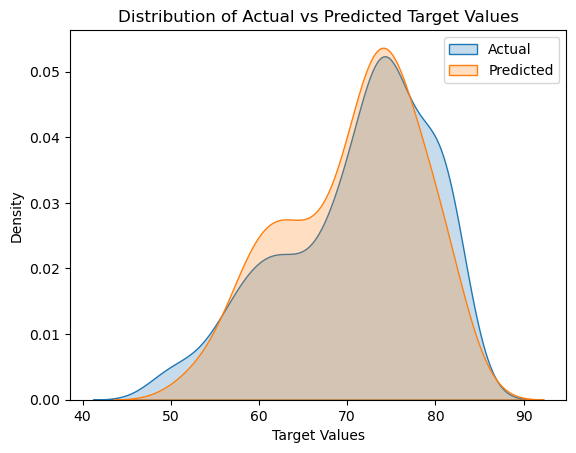

In [28]:
importancesXG = pd.Series(final_model.named_steps['xgb'].feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=importancesXG, y=importancesXG.index)
plt.title("Key Factors Influencing Life Expectancy")
plt.show()


# Check to see if distribution of actual target values is close to the distribution of predicted target values, with legend and shading for better visualization
sns.kdeplot(train_df[target], label='Actual', shade=True)
sns.kdeplot(test_preds, label='Predicted', shade=True)
plt.legend()
plt.title("Distribution of Actual vs Predicted Target Values")
plt.xlabel("Target Values")
plt.ylabel("Density")
plt.show()